# Accuracy histograms from edited Excel files

Put this notebook in:

```text
scripts/analysis/
```

It reads the three edited Excel files from:

```text
scripts/analysis/xl/
```

Expected files:

```text
abstract_results_FINAL.xlsx
nl_results_FINAL.xlsx
ttl_results_FINAL.xlsx
```

It combines the three settings and creates histograms for:

```text
C1 AxiomTypes
C9 AxiomTypeDiff
Justification Complexity Score
```

`C7 ModalDepth` and `C8 SignatureDifference` are loaded and diagnosed, but not plotted by default because they are expected to be always 0 in this FamilyOWL 1-hop run.

Plot style:

- bar = overall accuracy across all models and all three settings
- dots = per-model accuracy
- x-axis = difficulty value
- x-axis count = number of task-setting rows in that bin

Outputs are saved to:

```text
data/output/difficulty_accuracy_histograms_from_xl/
```

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Configuration
# ============================================================

EXCEL_FILENAMES = {
    "abstract": "abstract_results_FINAL.xlsx",
    "nl": "nl_results_FINAL.xlsx",
    "ttl": "ttl_results_FINAL.xlsx",
}

DIFFICULTY_FEATURES_TO_PLOT = [
    "C1 AxiomTypes",
    "C9 AxiomTypeDiff",
    "Justification Complexity Score",
]

DIAGNOSTIC_FEATURES = [
    "C7 ModalDepth",
    "C8 SignatureDifference",
]

OUTPUT_FOLDER_NAME = "difficulty_accuracy_histograms_from_xl"

# Leave as None to include all settings.
# Example: SETTINGS_TO_INCLUDE = ["abstract", "ttl"]
SETTINGS_TO_INCLUDE = None

# Leave as None to include all detected models.
# Example: MODELS_TO_INCLUDE = ["gpt-5-mini", "deepseek-chat"]
MODELS_TO_INCLUDE = None


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pom.xml").exists() and (parent / "data").exists():
            return parent
    raise FileNotFoundError(
        "Could not find repo root. Run this notebook from inside CORE-LLM-Bench-MasterProject2."
    )


REPO_ROOT = find_repo_root(Path.cwd())
ANALYSIS_DIR = REPO_ROOT / "scripts" / "analysis"
XL_DIR = ANALYSIS_DIR / "xl"
OUTPUT_DIR = REPO_ROOT / "data" / "output" / OUTPUT_FOLDER_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_PATHS = {
    setting: XL_DIR / filename
    for setting, filename in EXCEL_FILENAMES.items()
}

print("Repo root:", REPO_ROOT)
print("Excel folder:", XL_DIR)
print("Output folder:", OUTPUT_DIR)
print()
print("Input files:")
for setting, path in EXCEL_PATHS.items():
    print(f" - {setting}: {path}")

Repo root: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2
Excel folder: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\scripts\analysis\xl
Output folder: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl

Input files:
 - abstract: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\scripts\analysis\xl\abstract_results_FINAL.xlsx
 - nl: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\scripts\analysis\xl\nl_results_FINAL.xlsx
 - ttl: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\scripts\analysis\xl\ttl_results_FINAL.xlsx


In [3]:
# ============================================================
# Helpers
# ============================================================

def clean_column_name(col) -> str:
    return str(col).strip()


def normalize_col_key(col) -> str:
    return re.sub(r"[^a-z0-9]", "", str(col).strip().lower())


def find_column(df: pd.DataFrame, expected_name: str) -> str:
    expected_key = normalize_col_key(expected_name)
    for col in df.columns:
        if normalize_col_key(col) == expected_key:
            return col
    raise KeyError(
        f"Could not find column '{expected_name}'. Available columns: {list(df.columns)}"
    )


def parse_correctness_value(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if text in {"1", "1.0", "true", "yes", "y", "correct", "right"}:
        return 1.0

    if text in {"0", "0.0", "false", "no", "n", "incorrect", "wrong"}:
        return 0.0

    try:
        number = float(text)
        if 0.0 <= number <= 1.0:
            return number
    except Exception:
        pass

    return np.nan


def model_name_from_correctness_column(col: str) -> str:
    return str(col).replace("_quality_correctness", "")


def safe_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

In [4]:
# ============================================================
# Load and combine the three edited Excel files
# ============================================================

def load_one_setting(setting: str, path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing Excel file for setting '{setting}': {path}")

    df = pd.read_excel(path, dtype=str)
    df.columns = [clean_column_name(c) for c in df.columns]

    task_id_col = find_column(df, "Task ID")

    difficulty_cols = {
        feature: find_column(df, feature)
        for feature in DIFFICULTY_FEATURES_TO_PLOT + DIAGNOSTIC_FEATURES
    }

    correctness_cols = [
        col for col in df.columns
        if str(col).endswith("_quality_correctness")
    ]

    if not correctness_cols:
        raise ValueError(
            f"No *_quality_correctness columns found in {path.name}. "
            f"Columns: {list(df.columns)}"
        )

    long_rows = []

    for _, row in df.iterrows():
        task_id = str(row[task_id_col]).strip() if not pd.isna(row[task_id_col]) else ""

        if not task_id:
            continue

        base = {
            "setting": setting,
            "Task ID": task_id,
            "task_setting_id": f"{setting}||{task_id}",
        }

        for feature, real_col in difficulty_cols.items():
            base[feature] = row[real_col]

        for corr_col in correctness_cols:
            model = model_name_from_correctness_column(corr_col)
            correct = parse_correctness_value(row[corr_col])

            if pd.isna(correct):
                continue

            item = base.copy()
            item["model"] = model
            item["correct"] = float(correct)
            long_rows.append(item)

    out = pd.DataFrame(long_rows)

    for feature in DIFFICULTY_FEATURES_TO_PLOT + DIAGNOSTIC_FEATURES:
        out[feature] = safe_numeric(out[feature])

    return out


all_parts = []

for setting, path in EXCEL_PATHS.items():
    part = load_one_setting(setting, path)
    all_parts.append(part)
    print(f"{setting}: loaded {len(part)} model-answer rows from {path.name}")

combined_df = pd.concat(all_parts, ignore_index=True)

if SETTINGS_TO_INCLUDE is not None:
    combined_df = combined_df[combined_df["setting"].isin(SETTINGS_TO_INCLUDE)].copy()

if MODELS_TO_INCLUDE is not None:
    combined_df = combined_df[combined_df["model"].isin(MODELS_TO_INCLUDE)].copy()

combined_path = OUTPUT_DIR / "combined_long_accuracy_with_difficulty.csv"
combined_df.to_csv(combined_path, index=False)

print()
print("Combined rows:", len(combined_df))
print("Unique Task IDs:", combined_df["Task ID"].nunique())
print("Unique task-setting rows:", combined_df["task_setting_id"].nunique())
print("Settings:", sorted(combined_df["setting"].unique()))
print("Models:", sorted(combined_df["model"].unique()))
print("Saved combined long table:", combined_path)

display(combined_df.head())

abstract: loaded 4272 model-answer rows from abstract_results_FINAL.xlsx
nl: loaded 4197 model-answer rows from nl_results_FINAL.xlsx
ttl: loaded 4272 model-answer rows from ttl_results_FINAL.xlsx

Combined rows: 12741
Unique Task IDs: 763
Unique task-setting rows: 2281
Settings: ['abstract', 'nl', 'ttl']
Models: ['deepseek-chat', 'gpt-5-mini', 'llama-4-maverick']
Saved combined long table: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\combined_long_accuracy_with_difficulty.csv


,setting,Task ID,task_setting_id,C1 AxiomTypes,C9 AxiomTypeDiff,Justification Complexity Score,C7 ModalDepth,C8 SignatureDifference,model,correct
0,abstract,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,abstract||1hop-Thing_ada_rachel_heath_1868_gwe...,4.0,1.0,450.0,0.0,0.0,gpt-5-mini,1.0
1,abstract,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,abstract||1hop-Thing_ada_rachel_heath_1868_gwe...,4.0,1.0,450.0,0.0,0.0,deepseek-chat,0.0
2,abstract,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,abstract||1hop-Thing_ada_rachel_heath_1868_gwe...,4.0,1.0,450.0,0.0,0.0,llama-4-maverick,1.0
3,abstract,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,abstract||1hop-Thing_ada_rachel_heath_1868_gwe...,4.0,1.0,450.0,0.0,0.0,gpt-5-mini,0.0
4,abstract,1hop-Thing_ada_rachel_heath_1868_gwendoline_he...,abstract||1hop-Thing_ada_rachel_heath_1868_gwe...,4.0,1.0,450.0,0.0,0.0,deepseek-chat,0.0


In [5]:
# ============================================================
# Diagnostics: distributions and why C7/C8 are not plotted
# ============================================================

print("Overall accuracy by setting and model:")
display(
    combined_df
    .groupby(["setting", "model"], as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        n_model_answers=("correct", "size"),
        n_task_setting_rows=("task_setting_id", "nunique"),
    )
    .sort_values(["setting", "model"])
)

print("\nOverall accuracy by model, all settings combined:")
display(
    combined_df
    .groupby("model", as_index=False)
    .agg(
        accuracy=("correct", "mean"),
        n_model_answers=("correct", "size"),
        n_task_setting_rows=("task_setting_id", "nunique"),
    )
    .sort_values("model")
)

for feature in DIFFICULTY_FEATURES_TO_PLOT + DIAGNOSTIC_FEATURES:
    print(f"\nDistribution of {feature} across unique task-setting rows:")
    display(
        combined_df
        .drop_duplicates("task_setting_id")
        .groupby(feature, dropna=False)
        .agg(n_task_setting_rows=("task_setting_id", "nunique"))
        .reset_index()
        .sort_values(feature, na_position="last")
    )

Overall accuracy by setting and model:


,setting,model,accuracy,n_model_answers,n_task_setting_rows
0,abstract,deepseek-chat,0.070927,1424,763
1,abstract,gpt-5-mini,0.183989,1424,763
2,abstract,llama-4-maverick,0.154494,1424,763
3,nl,deepseek-chat,0.922300,1399,755
4,nl,gpt-5-mini,0.892299,1399,755
5,nl,llama-4-maverick,0.889071,1399,755
6,ttl,deepseek-chat,0.895975,1424,763
7,ttl,gpt-5-mini,0.872849,1424,763
8,ttl,llama-4-maverick,0.866408,1424,763



Overall accuracy by model, all settings combined:


,model,accuracy,n_model_answers,n_task_setting_rows
0,deepseek-chat,0.628012,4247,2281
1,gpt-5-mini,0.648284,4247,2281
2,llama-4-maverick,0.635172,4247,2281



Distribution of C1 AxiomTypes across unique task-setting rows:


...

,Justification Complexity Score,n_task_setting_rows
0,200.0,2152
1,350.0,12
2,450.0,72
3,550.0,30
4,NaN,15



Distribution of C7 ModalDepth across unique task-setting rows:


,C7 ModalDepth,n_task_setting_rows
0,0.0,2260
1,1.0,6
2,NaN,15



Distribution of C8 SignatureDifference across unique task-setting rows:


,C8 SignatureDifference,n_task_setting_rows
0,0.0,2266
1,NaN,15


## Why C7 and C8 are always 0 here

`C7 ModalDepth` is 0 when the justifications do not contain nested modal / role-restriction class expressions such as existential, universal, or cardinality restrictions. In this FamilyOWL 1-hop output, the explanations are mostly simple class assertions, property assertions, subclass axioms, subproperty axioms, inverse properties, or symmetry-style axioms, so there is no nested class-expression depth to count.

`C8 SignatureDifference` is 0 when every entity appearing in the query axiom also appears in the justification signature. Since the explanation is generated for the exact queried triple, the subject, predicate, and object/class usually already occur inside the explanation axioms. Therefore the query signature minus the justification signature is empty.

So for this run, `C1`, `C9`, and the final score are more useful for plotting.

In [6]:
# ============================================================
# Histogram-style accuracy plot
# ============================================================

def make_feature_accuracy_tables(df: pd.DataFrame, feature: str):
    working = df.dropna(subset=[feature, "model", "correct"]).copy()

    if working.empty:
        raise ValueError(f"No usable rows for feature: {feature}")

    # Keep values as numbers for ordering.
    working["_feature_value"] = pd.to_numeric(working[feature], errors="coerce")
    working = working.dropna(subset=["_feature_value"]).copy()

    # If all values are integer-like, display them as ints.
    all_integer = np.allclose(
        working["_feature_value"].dropna(),
        working["_feature_value"].dropna().round(),
    )

    if all_integer:
        working["_feature_label"] = working["_feature_value"].round().astype(int).astype(str)
        working["_feature_order"] = working["_feature_value"].round().astype(int)
    else:
        working["_feature_label"] = working["_feature_value"].round(4).astype(str)
        working["_feature_order"] = working["_feature_value"]

    overall = (
        working
        .groupby(["_feature_label", "_feature_order"], as_index=False)
        .agg(
            overall_accuracy=("correct", "mean"),
            n_model_answers=("correct", "size"),
            n_task_setting_rows=("task_setting_id", "nunique"),
            n_unique_tasks=("Task ID", "nunique"),
        )
        .sort_values("_feature_order")
        .reset_index(drop=True)
    )

    per_model = (
        working
        .groupby(["_feature_label", "_feature_order", "model"], as_index=False)
        .agg(
            model_accuracy=("correct", "mean"),
            n_model_answers=("correct", "size"),
            n_task_setting_rows=("task_setting_id", "nunique"),
            n_unique_tasks=("Task ID", "nunique"),
        )
        .sort_values(["_feature_order", "model"])
        .reset_index(drop=True)
    )

    per_setting = (
        working
        .groupby(["_feature_label", "_feature_order", "setting"], as_index=False)
        .agg(
            setting_accuracy=("correct", "mean"),
            n_model_answers=("correct", "size"),
            n_task_setting_rows=("task_setting_id", "nunique"),
            n_unique_tasks=("Task ID", "nunique"),
        )
        .sort_values(["_feature_order", "setting"])
        .reset_index(drop=True)
    )

    return overall, per_model, per_setting


def plot_feature_accuracy_histogram(df: pd.DataFrame, feature: str, output_prefix: str):
    overall, per_model, per_setting = make_feature_accuracy_tables(df, feature)

    labels = overall["_feature_label"].tolist()
    x = np.arange(len(labels))

    fig_width = max(10, min(22, len(labels) * 1.2))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    ax.bar(
        x,
        overall["overall_accuracy"],
        width=0.65,
        alpha=0.35,
        label="overall accuracy",
    )

    models = sorted(per_model["model"].dropna().unique())
    offsets = [0.0] if len(models) == 1 else np.linspace(-0.22, 0.22, len(models))

    for offset, model in zip(offsets, models):
        model_rows = per_model[per_model["model"] == model]
        xs = []
        ys = []

        for i, label in enumerate(labels):
            row = model_rows[model_rows["_feature_label"] == label]
            if row.empty:
                continue
            xs.append(i + offset)
            ys.append(row["model_accuracy"].iloc[0])

        ax.scatter(xs, ys, s=80, label=model, zorder=3)

    x_tick_labels = [
        f"{label}\n(n={n})"
        for label, n in zip(overall["_feature_label"], overall["n_task_setting_rows"])
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel(f"{feature}\n(n = task-setting rows across abstract, nl, ttl)")
    ax.set_title(f"FamilyOWL 1-hop — Accuracy by {feature} — 3 settings combined")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Model / overall", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / f"{output_prefix}.png"
    overall_path = OUTPUT_DIR / f"{output_prefix}_overall.csv"
    per_model_path = OUTPUT_DIR / f"{output_prefix}_per_model.csv"
    per_setting_path = OUTPUT_DIR / f"{output_prefix}_per_setting.csv"

    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    overall.to_csv(overall_path, index=False)
    per_model.to_csv(per_model_path, index=False)
    per_setting.to_csv(per_setting_path, index=False)

    print("Saved plot:", plot_path)
    print("Saved overall CSV:", overall_path)
    print("Saved per-model CSV:", per_model_path)
    print("Saved per-setting CSV:", per_setting_path)

    plt.show()

    return overall, per_model, per_setting

Plotting: C1 AxiomTypes
Saved plot: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c1_axiomtypes.png
Saved overall CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c1_axiomtypes_overall.csv
Saved per-model CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c1_axiomtypes_per_model.csv
Saved per-setting CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c1_axiomtypes_per_setting.csv


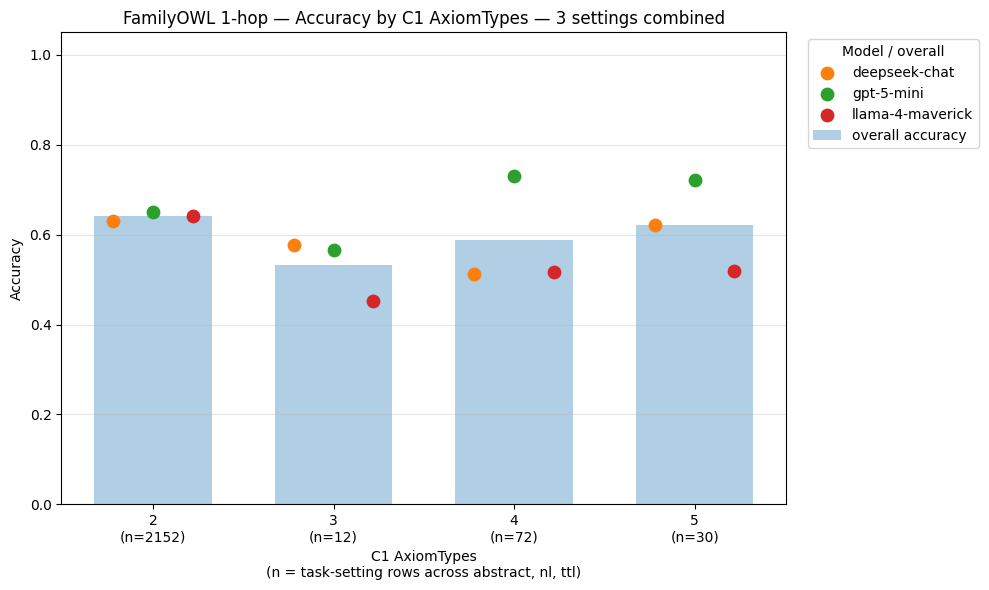


Plotting: C9 AxiomTypeDiff
Saved plot: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c9_axiomtypediff.png
Saved overall CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c9_axiomtypediff_overall.csv
Saved per-model CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c9_axiomtypediff_per_model.csv
Saved per-setting CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_c9_axiomtypediff_per_setting.csv


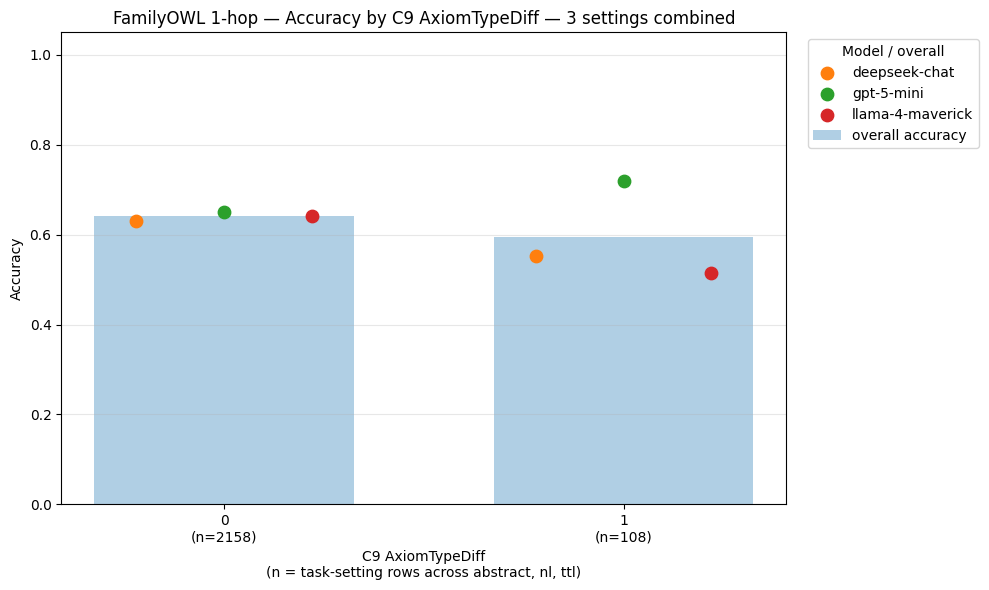


Plotting: Justification Complexity Score
Saved plot: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_justification_complexity_score.png
Saved overall CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_justification_complexity_score_overall.csv
Saved per-model CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_justification_complexity_score_per_model.csv
Saved per-setting CSV: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\hist_accuracy_justification_complexity_score_per_setting.csv


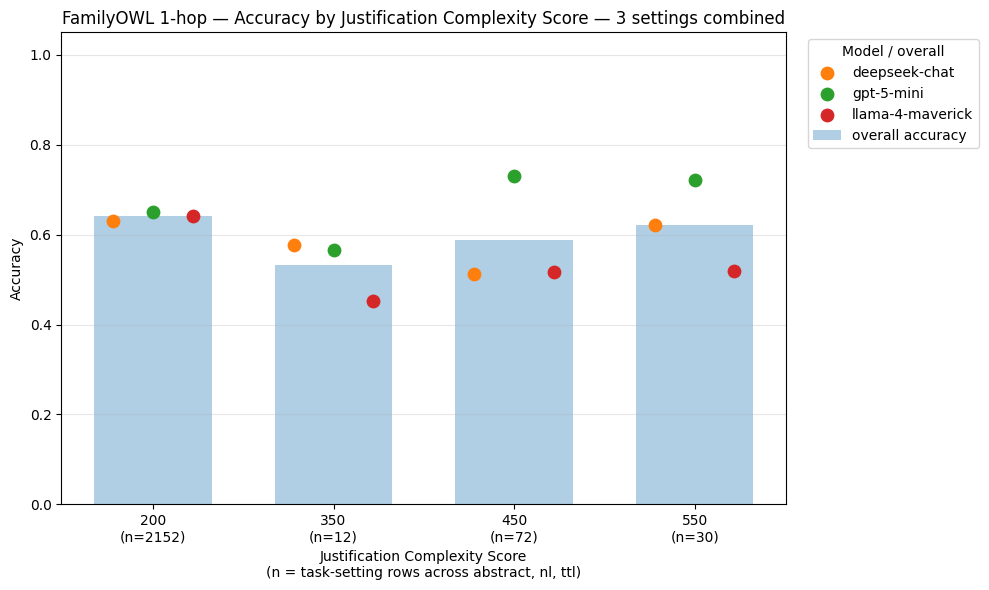

In [7]:
# ============================================================
# Create the three requested histograms
# ============================================================

plot_results = {}

feature_to_prefix = {
    "C1 AxiomTypes": "hist_accuracy_c1_axiomtypes",
    "C9 AxiomTypeDiff": "hist_accuracy_c9_axiomtypediff",
    "Justification Complexity Score": "hist_accuracy_justification_complexity_score",
}

for feature in DIFFICULTY_FEATURES_TO_PLOT:
    print("=" * 100)
    print("Plotting:", feature)
    output_prefix = feature_to_prefix[feature]
    plot_results[feature] = plot_feature_accuracy_histogram(
        combined_df,
        feature=feature,
        output_prefix=output_prefix,
    )
    print()

In [8]:
# ============================================================
# Optional: compact summary table for report writing
# ============================================================

summary_rows = []

for feature, (overall, per_model, per_setting) in plot_results.items():
    for _, row in overall.iterrows():
        summary_rows.append({
            "feature": feature,
            "value": row["_feature_label"],
            "overall_accuracy": row["overall_accuracy"],
            "n_model_answers": row["n_model_answers"],
            "n_task_setting_rows": row["n_task_setting_rows"],
            "n_unique_tasks": row["n_unique_tasks"],
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / "all_histogram_overall_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved combined summary:", summary_path)
display(summary_df)

Saved combined summary: C:\Users\abcma\OneDrive\Desktop\pro2\CORE-LLM-Bench-MasterProject2\data\output\difficulty_accuracy_histograms_from_xl\all_histogram_overall_summary.csv


,feature,value,overall_accuracy,n_model_answers,n_task_setting_rows,n_unique_tasks
0,C1 AxiomTypes,2,0.640985,11970,2152,720
1,C1 AxiomTypes,3,0.532270,63,12,4
2,C1 AxiomTypes,4,0.587066,348,72,24
3,C1 AxiomTypes,5,0.620359,153,30,10
4,C9 AxiomTypeDiff,0,0.640680,11988,2158,722
5,C9 AxiomTypeDiff,1,0.594989,546,108,36
6,Justification Complexity Score,200,0.640985,11970,2152,720
7,Justification Complexity Score,350,0.532270,63,12,4
8,Justification Complexity Score,450,0.587066,348,72,24
9,Justification Complexity Score,550,0.620359,153,30,10


## Output files

The notebook creates:

```text
data/output/difficulty_accuracy_histograms_from_xl/hist_accuracy_c1_axiomtypes.png
data/output/difficulty_accuracy_histograms_from_xl/hist_accuracy_c9_axiomtypediff.png
data/output/difficulty_accuracy_histograms_from_xl/hist_accuracy_justification_complexity_score.png
```

and CSV summaries:

```text
*_overall.csv
*_per_model.csv
*_per_setting.csv
all_histogram_overall_summary.csv
combined_long_accuracy_with_difficulty.csv
```

The plotted histograms combine all three settings:

```text
abstract + nl + ttl
```